In [4]:
pip install langgraph langchain-groq langchain-community langchain-core python-dotenv requests langgraph-checkpoint-sqlite

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.4/163.4 kB 5.6 MB/s eta 0:00:00


In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
from dotenv import load_dotenv
import sqlite3
import requests


/tmp/ipykernel_3240/3271075925.py:8: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


In [55]:
pip install -U ddgs

In [56]:
search_tool = DuckDuckGoSearchRun(region="us-en")

@tool
def calculator(first_num: float, second_num: float, operation: str) -> dict:
    """
    Perform a basic arithmetic operation on two numbers.
    Supported operations: add, sub, mul, div
    """
    try:
        if operation == "add":
            result = first_num + second_num
        elif operation == "sub":
            result = first_num - second_num
        elif operation == "mul":
            result = first_num * second_num
        elif operation == "div":
            if second_num == 0:
                return {"error": "Division by zero is not allowed"}
            result = first_num / second_num
        else:
            return {"error": f"Unsupported operation '{operation}'"}

        return {"first_num": first_num, "second_num": second_num, "operation": operation, "result": result}
    except Exception as e:
        return {"error": str(e)}




@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA')
    using Alpha Vantage with API key in the URL.
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=OPEDVRHVWCMPYPO7"
    r = requests.get(url)
    return r.json()

In [57]:
tools = [search_tool, get_stock_price, calculator]
llm_with_tools = model.bind_tools(tools)

In [58]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [59]:
def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)


In [60]:
conn = sqlite3.connect(database="chatbot.db", check_same_thread=False)
checkpointer = SqliteSaver(conn=conn)

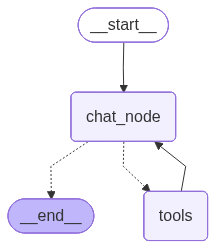

In [61]:
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

graph.add_edge(START, "chat_node")

graph.add_conditional_edges("chat_node",tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile(checkpointer=checkpointer)
chatbot

In [70]:
intial={
    "messages": [HumanMessage("what is stock prize of Meta for now")]
}

In [71]:
a=chatbot.invoke(intial, config={'configurable': {'thread_id': '4'}})
print(a)

print(a['messages'][-1].content)

{'messages': [HumanMessage(content='what is stock prize coduzion give me last 5 months stat', additional_kwargs={}, response_metadata={}, id='7df6dd41-d176-4ce2-bbbc-ef3340859457'), HumanMessage(content='what is stock prize Coduzion Technologies Pvt. Ltd. give me last 5 months stat', additional_kwargs={}, response_metadata={}, id='c3c88044-da9d-4531-a48d-ca7be280cd90'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'mxxhmjpkj', 'function': {'arguments': '{"symbol":"Coduzion Technologies Pvt. Ltd."}', 'name': 'get_stock_price'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 506, 'total_tokens': 527, 'completion_time': 0.056487519, 'completion_tokens_details': None, 'prompt_time': 0.045051926, 'prompt_tokens_details': None, 'queue_time': 0.062400353, 'total_time': 0.101539445}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'l